# Duelo Final — Random Forest Avançado
### Competição Titanic | Kaggle

**Estratégia:** Superar os resultados da aula utilizando Random Forest com:
- Feature engineering avançado (novas variáveis)
- Mais features do que as usadas em aula
- RandomizedSearchCV para otimização de hiperparâmetros
- StratifiedKFold para validação cruzada mais robusta
- SMOTE + StandardScaler no pré-processamento

## 1. Importação das Bibliotecas

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Modelo principal
from sklearn.ensemble import RandomForestClassifier

# Otimização de hiperparâmetros
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Reprodutibilidade
# OBS: neste trabalho vamos suprimir alertas para ter um ambiente mais limpor.
# Não tomamos isso como regra, pois alertas são importantes para garantir boa condução em projetos reais.
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [3]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Treino: {train_df.shape[0]} linhas x {train_df.shape[1]} colunas')
print(f'Teste:  {test_df.shape[0]} linhas x {test_df.shape[1]} colunas')

Treino: 891 linhas x 12 colunas
Teste:  418 linhas x 11 colunas


In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Visão geral dos dados de treino
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Verificando valores nulos
print('Valores nulos — Treino:')
print(train_df.isnull().sum())
print()
print('Valores nulos — Teste:')
print(test_df.isnull().sum())

Valores nulos — Treino:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valores nulos — Teste:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [7]:
# Distribuição da variável alvo
print('Distribuição da variável alvo (Survived):')
print(train_df['Survived'].value_counts())
print()
print(f'Taxa de sobrevivência: {train_df["Survived"].mean():.2%}')

Distribuição da variável alvo (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Taxa de sobrevivência: 38.38%


## 3. Feature Engineering

Esta é a principal diferença em relação à aula. Enquanto a aula utilizou apenas 4 features
(`Sex`, `Cabin_known`, `Fare`, `Pclass`), vamos criar novas variáveis que capturam
informações mais ricas sobre cada passageiro.

**Novas features criadas:**
- `Title`: título social extraído do nome (Mr, Mrs, Miss, Master, etc.)
- `FamilySize`: tamanho total da família a bordo
- `IsAlone`: indicador se o passageiro estava sozinho
- `FarePerPerson`: tarifa dividida pelo tamanho da família
- `AgeBand`: faixa etária categorizada
- `Cabin_known`: indica se a cabine é conhecida

In [8]:
def criar_features(df):
    """
    Aplica todas as transformações de feature engineering.
    Recebe um DataFrame e retorna o mesmo com novas colunas.
    """
    df = df.copy()

    # --- Extração do Título a partir do Nome ---
    # O nome tem o formato: 'Sobrenome, Titulo. Nome'
    df['Title'] = df['Name'].str.extract(r',\s([A-Za-z]+)\.')

    # Agrupando títulos raros em uma única categoria para evitar ruído
    titulos_raros = ['Dona', 'Lady', 'Countess', 'Capt', 'Col', 'Don',
                     'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Mlle', 'Ms', 'Mme']
    df['Title'] = df['Title'].replace(titulos_raros, 'Rare')

    # Codificando o título como número
    mapa_titulos = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
    df['Title'] = df['Title'].map(mapa_titulos).fillna(0).astype(int)

    # --- Tamanho da Família ---
    # SibSp = irmãos + cônjuge | Parch = pais + filhos
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 = o próprio passageiro

    # --- Indicador de viajante solo ---
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # --- Tarifa por pessoa ---
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # --- Cabin: conhecido ou não ---
    df['Cabin_known'] = df['Cabin'].notna().astype(int)

    return df


train_df = criar_features(train_df)
test_df  = criar_features(test_df)

print('Feature engineering aplicado com sucesso!')
print()
print('Distribuição dos títulos extraídos:')
print(train_df['Title'].value_counts())

Feature engineering aplicado com sucesso!

Distribuição dos títulos extraídos:
Title
1    517
2    182
3    125
4     40
5     26
0      1
Name: count, dtype: int64


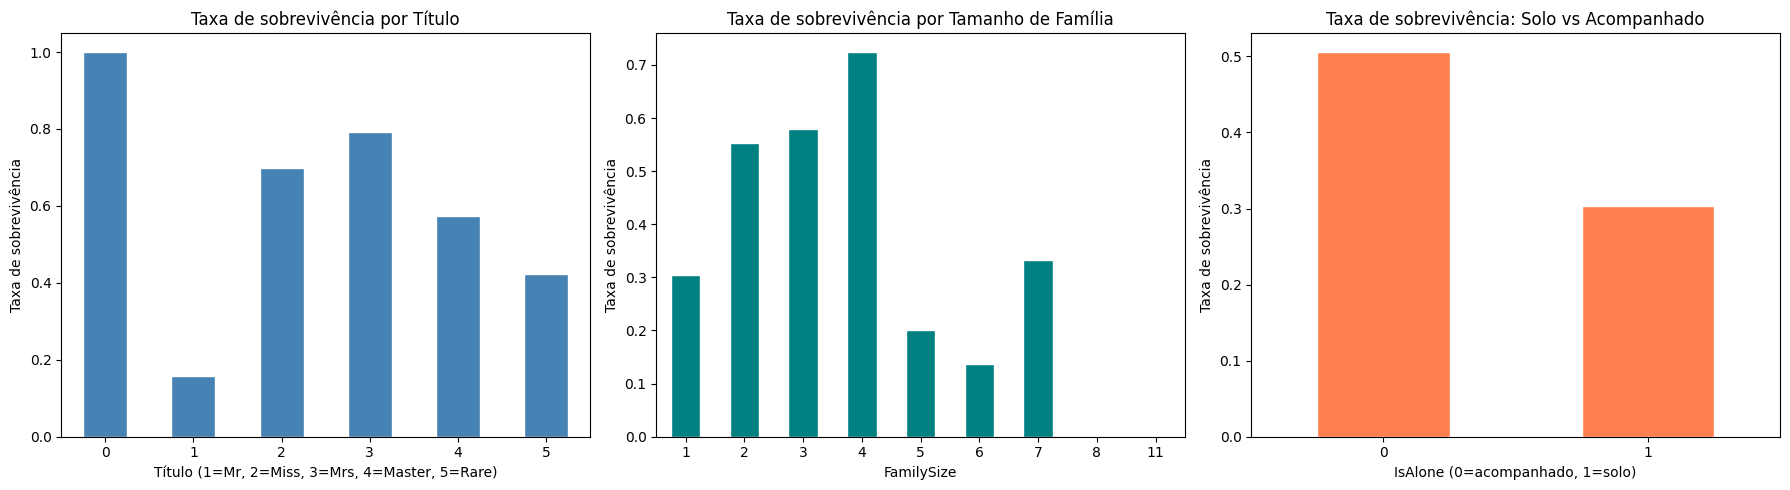

In [9]:
# Visualizando a taxa de sobrevivência por título
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por Título
title_survival = train_df.groupby('Title')['Survived'].mean()
title_survival.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taxa de sobrevivência por Título')
axes[0].set_xlabel('Título (1=Mr, 2=Miss, 3=Mrs, 4=Master, 5=Rare)')
axes[0].set_ylabel('Taxa de sobrevivência')
axes[0].tick_params(axis='x', rotation=0)

# Por tamanho de família
family_survival = train_df.groupby('FamilySize')['Survived'].mean()
family_survival.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Taxa de sobrevivência por Tamanho de Família')
axes[1].set_xlabel('FamilySize')
axes[1].set_ylabel('Taxa de sobrevivência')
axes[1].tick_params(axis='x', rotation=0)

# IsAlone
alone_survival = train_df.groupby('IsAlone')['Survived'].mean()
alone_survival.plot(kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Taxa de sobrevivência: Solo vs Acompanhado')
axes[2].set_xlabel('IsAlone (0=acompanhado, 1=solo)')
axes[2].set_ylabel('Taxa de sobrevivência')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Pré-processamento dos Dados

In [10]:
# Codificação de variáveis categóricas

# Sex: Label Encoding (apenas 2 categorias)
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex']  = test_df['Sex'].map({'male': 0, 'female': 1})

# Embarked: One-Hot Encoding (mais de 2 categorias)
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df  = pd.get_dummies(test_df,  columns=['Embarked'], prefix='Embarked')

# Garantindo que as colunas Embarked existam em ambos os datasets
for col in ['Embarked_C', 'Embarked_Q', 'Embarked_S']:
    if col not in test_df.columns:
        test_df[col] = 0

print('Codificação aplicada com sucesso!')

Codificação aplicada com sucesso!


In [11]:
# Tratamento de valores nulos

# Age: imputamos com a mediana por grupo (Pclass + Sex)
# Mediana é mais robusta que a média quando há outliers
for df in [train_df, test_df]:
    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

# Fare: apenas 1 nulo no teste — usamos a mediana por Pclass
test_df['Fare'] = test_df.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# Recalculando FarePerPerson após imputação
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']
test_df['FarePerPerson']  = test_df['Fare']  / test_df['FamilySize']

print('Valores nulos tratados!')
print()
print('Nulos restantes — Treino:', train_df.isnull().sum().sum())
print('Nulos restantes — Teste: ', test_df.isnull().sum().sum())

Valores nulos tratados!

Nulos restantes — Treino: 687
Nulos restantes — Teste:  327


In [12]:
# Definindo as features que serão usadas no modelo
# Aqui usamos MUITO mais variáveis do que na aula (que usou apenas 4)

FEATURES = [
    'Pclass',         # Classe do bilhete
    'Sex',            # Gênero
    'Age',            # Idade (com imputação inteligente)
    'SibSp',          # Irmãos/cônjuge
    'Parch',          # Pais/filhos
    'Fare',           # Tarifa
    'Cabin_known',    # Cabine conhecida?
    'Title',          # Título social (NOVO)
    'FamilySize',     # Tamanho da família (NOVO)
    'IsAlone',        # Viajando sozinho? (NOVO)
    'FarePerPerson',  # Tarifa por pessoa (NOVO)
    'Embarked_C',     # Porto de embarque
    'Embarked_Q',
    'Embarked_S',
]

X      = train_df[FEATURES]
y      = train_df['Survived']
X_test = test_df[FEATURES]

print(f'Features utilizadas: {len(FEATURES)}')
print(f'Shape X treino: {X.shape}')
print(f'Shape X teste:  {X_test.shape}')

Features utilizadas: 14
Shape X treino: (891, 14)
Shape X teste:  (418, 14)


## 5. Balanceamento e Padronização

In [13]:
# Verificando o desbalanceamento antes do SMOTE
print('Distribuição antes do balanceamento:')
print(y.value_counts())
print(f'Proporção: {y.mean():.2%} de sobreviventes')

Distribuição antes do balanceamento:
Survived
0    549
1    342
Name: count, dtype: int64
Proporção: 38.38% de sobreviventes


In [14]:
# Aplicando SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print('Distribuição após SMOTE:')
print(pd.Series(y_balanced).value_counts())

Distribuição após SMOTE:
Survived
0    549
1    549
Name: count, dtype: int64


In [15]:
# Padronizando os dados (importante para estabilidade do modelo)
scaler = StandardScaler()
X_balanced_scaled = scaler.fit_transform(X_balanced)
X_test_scaled     = scaler.transform(X_test)

print('Padronização aplicada!')
print(f'Shape treino balanceado e padronizado: {X_balanced_scaled.shape}')

Padronização aplicada!
Shape treino balanceado e padronizado: (1098, 14)


## 6. Duelo 1 — Modelo Base (sem otimização)

Começamos com o Random Forest padrão como baseline,
para entender o ponto de partida antes das otimizações.

In [16]:
# Modelo base — sem ajuste de hiperparâmetros
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_balanced_scaled, y_balanced)

y_pred_base = rf_base.predict(X_balanced_scaled)

print('=== Random Forest — Modelo Base ===')
print(classification_report(y_balanced, y_pred_base))

=== Random Forest — Modelo Base ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       549
           1       0.99      0.98      0.99       549

    accuracy                           0.99      1098
   macro avg       0.99      0.99      0.99      1098
weighted avg       0.99      0.99      0.99      1098



In [17]:
# Cross-validation com StratifiedKFold no modelo base
# StratifiedKFold garante que cada fold tenha a mesma proporção de classes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_base = cross_val_score(
    rf_base, X_balanced_scaled, y_balanced,
    cv=skf, scoring='accuracy'
)

print('Cross-Validation — Modelo Base:')
print(f'Scores por fold: {cv_scores_base.round(4)}')
print(f'Média:  {cv_scores_base.mean():.4f}')
print(f'Desvio: {cv_scores_base.std():.4f}')

Cross-Validation — Modelo Base:
Scores por fold: [0.8318 0.8364 0.8318 0.8128 0.8037]
Média:  0.8233
Desvio: 0.0127


## 7. Duelo 2 — Otimização com RandomizedSearchCV

Utilizamos `RandomizedSearchCV` em vez do `GridSearchCV` da aula.

**Por que RandomizedSearchCV?**
- Explora um espaço de parâmetros muito maior de forma eficiente
- Não testa todas as combinações (o que seria inviável aqui)
- Estatisticamente, tende a encontrar combinações tão boas quanto o GridSearch em menos tempo
- Ideal quando temos muitos hiperparâmetros para ajustar

In [18]:
# Grade de hiperparâmetros — muito mais ampla do que na aula
param_dist = {
    'n_estimators':      [100, 200, 300, 500],        # Número de árvores
    'max_depth':         [None, 5, 10, 15, 20, 30],   # Profundidade máxima
    'min_samples_split': [2, 5, 10, 15],              # Mín. amostras para dividir nó
    'min_samples_leaf':  [1, 2, 4, 6],                # Mín. amostras por folha
    'max_features':      ['sqrt', 'log2', None],      # Features por divisão
    'bootstrap':         [True, False],               # Amostragem com reposição
    'class_weight':      ['balanced', None],          # Pesos das classes
}

print('Grade de hiperparâmetros definida!')
total = 4 * 6 * 4 * 4 * 3 * 2 * 2
print(f'Total de combinações possíveis: {total:,}')
print('Número de combinações testadas pelo RandomizedSearchCV: 100')

Grade de hiperparâmetros definida!
Total de combinações possíveis: 4,608
Número de combinações testadas pelo RandomizedSearchCV: 100


In [19]:
# Executando o RandomizedSearchCV
rf_otimizado = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_otimizado,
    param_distributions=param_dist,
    n_iter=100,               # Número de combinações a testar
    scoring='accuracy',
    cv=skf,                   # StratifiedKFold com 5 folds
    n_jobs=-1,                # Usa todos os processadores disponíveis
    random_state=42,
    verbose=1
)

random_search.fit(X_balanced_scaled, y_balanced)

print()
print('=== Resultados do RandomizedSearchCV ===')
print(f'Melhores parâmetros: {random_search.best_params_}')
print(f'Melhor acurácia (CV): {random_search.best_score_:.4f}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits

=== Resultados do RandomizedSearchCV ===
Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'class_weight': None, 'bootstrap': True}
Melhor acurácia (CV): 0.8515


In [20]:
# Avaliando o melhor modelo no conjunto de treino
melhor_modelo = random_search.best_estimator_
y_pred_otimizado = melhor_modelo.predict(X_balanced_scaled)

print('=== Random Forest — Modelo Otimizado ===')
print(classification_report(y_balanced, y_pred_otimizado))

=== Random Forest — Modelo Otimizado ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       549
           1       0.97      0.96      0.96       549

    accuracy                           0.96      1098
   macro avg       0.96      0.96      0.96      1098
weighted avg       0.96      0.96      0.96      1098



In [21]:
# Cross-validation do modelo otimizado
cv_scores_otimizado = cross_val_score(
    melhor_modelo, X_balanced_scaled, y_balanced,
    cv=skf, scoring='accuracy'
)

print('Cross-Validation — Modelo Otimizado:')
print(f'Scores por fold: {cv_scores_otimizado.round(4)}')
print(f'Média:  {cv_scores_otimizado.mean():.4f}')
print(f'Desvio: {cv_scores_otimizado.std():.4f}')
print()
print(f'Melhora em relação ao modelo base: '
      f'{(cv_scores_otimizado.mean() - cv_scores_base.mean()):.4f}')

Cross-Validation — Modelo Otimizado:
Scores por fold: [0.8773 0.8591 0.8591 0.8311 0.8311]
Média:  0.8515
Desvio: 0.0180

Melhora em relação ao modelo base: 0.0282


## 8. Análise de Importância das Features

Uma das vantagens do Random Forest é que ele fornece a importância
de cada feature automaticamente. Isso nos ajuda a entender quais
variáveis mais influenciaram as previsões.

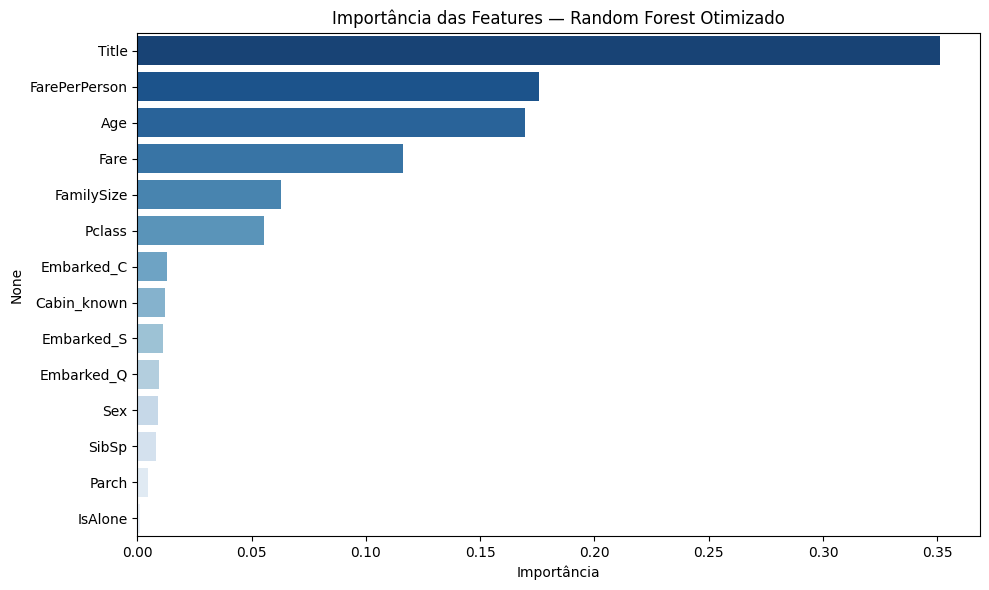


Importância por feature:
Title            0.3511
FarePerPerson    0.1759
Age              0.1697
Fare             0.1163
FamilySize       0.0629
Pclass           0.0553
Embarked_C       0.0131
Cabin_known      0.0123
Embarked_S       0.0112
Embarked_Q       0.0093
Sex              0.0089
SibSp            0.0081
Parch            0.0045
IsAlone          0.0013
dtype: float64


In [22]:
# Importância das features
importancias = pd.Series(
    melhor_modelo.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importancias.values,
    y=importancias.index,
    palette='Blues_r'
)
plt.title('Importância das Features — Random Forest Otimizado')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print('\nImportância por feature:')
print(importancias.round(4))

## 9. Matriz de Confusão

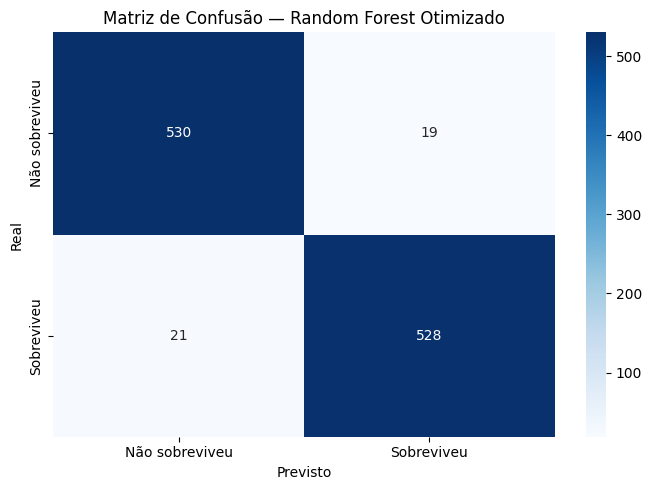

In [23]:
# Matriz de confusão do modelo otimizado
cm = confusion_matrix(y_balanced, y_pred_otimizado)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Não sobreviveu', 'Sobreviveu'],
    yticklabels=['Não sobreviveu', 'Sobreviveu']
)
plt.title('Matriz de Confusão — Random Forest Otimizado')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

## 10. Comparativo: Base vs Otimizado

In [24]:
# Resumo comparativo
print('=' * 50)
print('COMPARATIVO DE MODELOS')
print('=' * 50)
print(f'Modelo Base     — CV Accuracy: {cv_scores_base.mean():.4f} (± {cv_scores_base.std():.4f})')
print(f'Modelo Otimizado— CV Accuracy: {cv_scores_otimizado.mean():.4f} (± {cv_scores_otimizado.std():.4f})')
print()
print(f'Melhora obtida: +{(cv_scores_otimizado.mean() - cv_scores_base.mean()) * 100:.2f} pontos percentuais')
print('=' * 50)

COMPARATIVO DE MODELOS
Modelo Base     — CV Accuracy: 0.8233 (± 0.0127)
Modelo Otimizado— CV Accuracy: 0.8515 (± 0.0180)

Melhora obtida: +2.82 pontos percentuais


## 11. Geração das Previsões para o Kaggle

Geramos o arquivo de submissão no formato esperado pela competição do Kaggle:
duas colunas — `PassengerId` e `Survived`.

In [25]:
# Gerando previsões com o melhor modelo
y_pred_kaggle = melhor_modelo.predict(X_test_scaled)

print(f'Previsões geradas: {len(y_pred_kaggle)}')
print(f'Distribuição das previsões:')
print(pd.Series(y_pred_kaggle).value_counts())
print(f'Taxa prevista de sobrevivência: {y_pred_kaggle.mean():.2%}')

Previsões geradas: 418
Distribuição das previsões:
0    252
1    166
Name: count, dtype: int64
Taxa prevista de sobrevivência: 39.71%


In [26]:
# Criando o arquivo de submissão
submissao = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    y_pred_kaggle
})

submissao.to_csv('submission_random_forest.csv', index=False)

print('Arquivo de submissão gerado: submission_random_forest.csv')
print()
print('Prévia das primeiras linhas:')
print(submissao.head(10))

Arquivo de submissão gerado: submission_random_forest.csv

Prévia das primeiras linhas:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


## 12. Resumo Final

### O que fizemos de diferente em relação à aula:

| Aspecto | Aula (M41) | Este notebook |
|---|---|---|
| Modelo | SVM / XGBoost | Random Forest |
| Nº de features | 4 | 14 |
| Feature engineering | Nenhum | Title, FamilySize, IsAlone, FarePerPerson |
| Imputação de Age | Média global | Mediana por Pclass+Sex |
| Otimização | GridSearchCV | RandomizedSearchCV (100 iter.) |
| Cross-validation | KFold padrão | StratifiedKFold (5 folds) |

### Arquivo para submissão:
`submission_random_forest.csv`

Envie este arquivo na competição do Titanic no Kaggle:
https://www.kaggle.com/competitions/titanic